# Autoencoders — PyTorch (GPU-Accelerated)

## Model: Dense Autoencoder + Convolutional Denoising Autoencoder
- **Dataset**: CIFAR-10 — 50,000 train / 10,000 test, 3,072 features (32×32×3 RGB)
- **Task**: Reconstruct input images through bottleneck compression (self-supervised)
- **Framework showcase**: Conv Denoising AE — architecture sweep + noise level sweep on GPU

## GPU Acceleration Strategy
- All tensor ops on CUDA (encoder, decoder, loss computation)
- `nn.Module` subclass for both dense and convolutional architectures
- Adam optimizer with mini-batch training via DataLoader
- Gaussian noise injection: `torch.clamp(clean + σ * torch.randn_like(clean), 0, 1)`

## Evaluation Strategy
- **Metrics**: Reconstruction MSE/MAE, downstream KNN accuracy (K=5) on latent features
- **Visualizations**: Reconstruction grids (RGB), training loss curves, latent space t-SNE

## Pipeline
1. Load data + config
2. Simple dense autoencoder (baseline, match SK)
3. Training history + reconstruction visualization
4. Conv denoising AE — architecture sweep (showcase)
5. Dense vs best conv denoising comparison
6. Latent space + downstream classification
7. Performance benchmarks
8. Save results

In [1]:
# Step 1: Setup

"""
Imports, config, load preprocessed CIFAR-10, GPU tensors
Dense AE baseline matches SK (3072-512-128-512-3072)
Conv denoising AE uses image-shaped data (3, 32, 32)
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_training_history, plot_reconstruction_grid,
                                  plot_latent_space)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
MODEL_NAME = "Autoencoder"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

IMAGE_SHAPE = (32, 32, 3)
N_FEATURES = 3072  # 32 * 32 * 3
N_CHANNELS = 3
BATCH_SIZE = 128
LATENT_DIM = 128  # Baseline bottleneck (matches SK)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Reproducibility
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load preprocessed CIFAR-10 — flattened for dense AE
X_train_flat, X_test_flat, y_train, y_test, metadata = load_processed_data('autoencoder')

# Image-shaped data for conv AE
X_train_img = np.load('../../data/processed/autoencoder/X_train_img.npy')
X_test_img = np.load('../../data/processed/autoencoder/X_test_img.npy')

# GPU tensors — flattened (dense AE)
X_train_t = torch.tensor(X_train_flat, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test_flat, dtype=torch.float32, device=device)

# GPU tensors — image-shaped, channel-first for Conv2d: (N, 32, 32, 3) → (N, 3, 32, 32)
X_train_img_t = torch.tensor(X_train_img, dtype=torch.float32, device=device).permute(0, 3, 1, 2)
X_test_img_t = torch.tensor(X_test_img, dtype=torch.float32, device=device).permute(0, 3, 1, 2)

y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

# DataLoaders — input IS the target (self-supervised reconstruction)
train_flat_ds = TensorDataset(X_train_t, X_train_t)
train_flat_loader = DataLoader(train_flat_ds, batch_size=BATCH_SIZE, shuffle=True)

train_img_ds = TensorDataset(X_train_img_t, X_train_img_t)
train_img_loader = DataLoader(train_img_ds, batch_size=BATCH_SIZE, shuffle=True)

print("=" * 60)
print(f"[1/8] Data loaded — {FRAMEWORK} {MODEL_NAME}")
print("=" * 60)
print(f"  Device: {device} ({torch.cuda.get_device_name(0)})")
print(f"  Train flat: {X_train_t.shape} | Test flat: {X_test_t.shape}")
print(f"  Train img:  {X_train_img_t.shape} | Test img:  {X_test_img_t.shape}")
print(f"  Classes: {len(CLASS_NAMES)}")
print(f"  Batch size: {BATCH_SIZE} ({len(train_flat_loader)} batches/epoch)")
print(f"  Pixel range: [{X_train_t.min():.1f}, {X_train_t.max():.1f}]")
print(f"  GPU memory: {torch.cuda.memory_allocated() / 1e6:.1f} MB")

[1/8] Data loaded — PyTorch Autoencoder
  Device: cuda (NVIDIA GeForce RTX 4090)
  Train flat: torch.Size([50000, 3072]) | Test flat: torch.Size([10000, 3072])
  Train img:  torch.Size([50000, 3, 32, 32]) | Test img:  torch.Size([10000, 3, 32, 32])
  Classes: 10
  Batch size: 128 (391 batches/epoch)
  Pixel range: [0.0, 1.0]
  GPU memory: 1476.9 MB


In [2]:
# Step 2: Simple Dense Autoencoder

"""
Same architecture as SK: 3072 → 512 → 128 → 512 → 3072
Sigmoid output maps to [0,1] pixel space
Mini-batch training with early stopping on validation loss
"""

print("=" * 60)
print("[2/8] Simple Dense Autoencoder — Baseline")
print("=" * 60)

class DenseAutoencoder(nn.Module):
    # Symmetric dense autoencoder with configurable bottleneck.
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Output in [0,1] for pixel reconstruction
        )

    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        return recon

    def encode(self, x):
        return self.encoder(x)

# Build model — matches SK's 3072-512-128-512-3072
dense_ae = DenseAutoencoder(N_FEATURES, 512, LATENT_DIM).to(device)
optimizer = optim.Adam(dense_ae.parameters())
criterion = nn.MSELoss()

# Train/val split (90/10)
n_val = int(len(X_train_t) * 0.1)
indices = torch.randperm(len(X_train_t), device=device,
                          generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
val_idx, train_idx = indices[:n_val], indices[n_val:]

X_val_flat = X_train_t[val_idx]
X_train_split = X_train_t[train_idx]

train_ds = TensorDataset(X_train_split, X_train_split)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# Training loop with early stopping
MAX_EPOCHS = 200
PATIENCE = 15
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []

with track_performance(gpu=True) as perf:
    for epoch in range(MAX_EPOCHS):
        # Train
        dense_ae.train()
        epoch_loss = 0.0
        for batch_x, batch_target in train_loader:
            optimizer.zero_grad()
            recon = dense_ae(batch_x)
            loss = criterion(recon, batch_target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_x)
        train_loss = epoch_loss / len(X_train_split)
        train_losses.append(train_loss)

        # Validate
        dense_ae.eval()
        with torch.no_grad():
            val_recon = dense_ae(X_val_flat)
            val_loss = criterion(val_recon, X_val_flat).item()
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in dense_ae.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    torch.cuda.synchronize()

# Restore best weights
dense_ae.load_state_dict(best_state)
best_epoch = len(train_losses) - PATIENCE

# Reconstruct test set
dense_ae.eval()
with torch.no_grad():
    X_test_recon_t = dense_ae(X_test_t)
X_test_recon = X_test_recon_t.cpu().numpy()

# Reconstruction metrics
baseline_mse = np.mean((X_test_flat - X_test_recon) ** 2)
baseline_mae = np.mean(np.abs(X_test_flat - X_test_recon))

n_params = sum(p.numel() for p in dense_ae.parameters())

print(f"\nArchitecture: 3072 → 512 → 128 → 512 → 3072")
print(f"Epochs: {len(train_losses)} (early stopped at best epoch {best_epoch})")
print(f"Best val loss: {best_val_loss:.6f}")
print(f"Training time: {perf['time']:.2f}s")
print(f"GPU memory: {perf['gpu_memory']:.2f} MB")
print(f"Peak CPU memory: {perf['memory']:.2f} MB")
print(f"\nReconstruction Quality (test set):")
print(f"  MSE:  {baseline_mse:.6f}")
print(f"  MAE:  {baseline_mae:.6f}")
print(f"  RMSE: {np.sqrt(baseline_mse):.6f}")
print(f"\nParameters: {n_params:,}")
print(f"\nSK baseline comparison: MSE 0.0133 (10K subset)")

[2/8] Simple Dense Autoencoder — Baseline

Architecture: 3072 → 512 → 128 → 512 → 3072
Epochs: 125 (early stopped at best epoch 110)
Best val loss: 0.009058
Training time: 114.00s
GPU memory: 2255.86 MB
Peak CPU memory: 1.92 MB

Reconstruction Quality (test set):
  MSE:  0.009055
  MAE:  0.068719
  RMSE: 0.095160

Parameters: 3,281,024

SK baseline comparison: MSE 0.0133 (10K subset)


[3/8] Visualizations


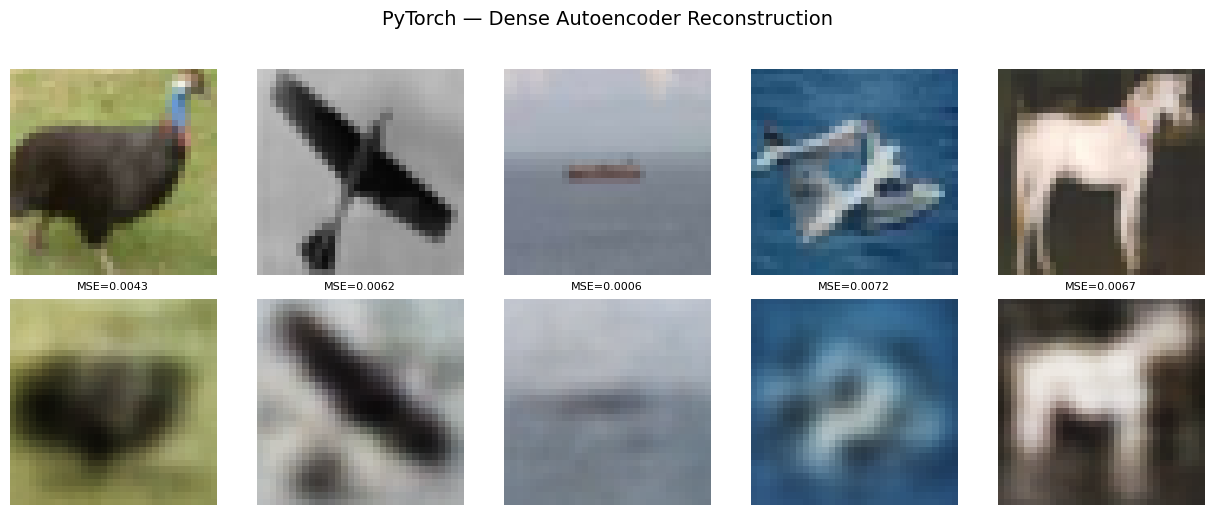

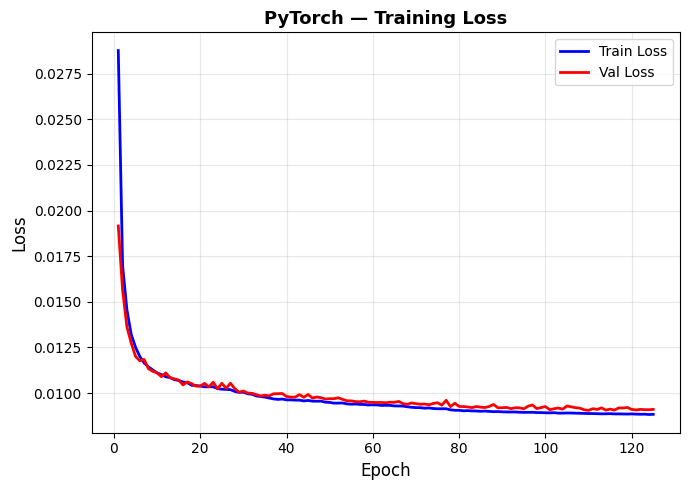


Training: 125 epochs
Final train loss: 0.008839
Best val loss:    0.009058 (epoch 110)


In [3]:
# Step 3: Visualizations

# Reconstruction grid (RGB) + training loss curve


print("=" * 60)
print("[3/8] Visualizations")
print("=" * 60)

# Reconstruction Grid
rng_viz = np.random.RandomState(RANDOM_STATE)
viz_idx = rng_viz.choice(len(X_test_flat), 5, replace=False)

recon_dict = {128: X_test_recon[viz_idx]}
plot_reconstruction_grid(
    originals=X_test_flat[viz_idx],
    reconstructions_dict=recon_dict,
    image_shape=IMAGE_SHAPE,
    n_samples=5,
    title='Dense Autoencoder Reconstruction',
    row_label_prefix='dim',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/reconstruction_dense.png'
)

# Training Loss Curve
history = {
    'train_loss': train_losses,
    'val_loss': val_losses
}

plot_training_history(
    history=history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_dense.png'
)

print(f"\nTraining: {len(train_losses)} epochs")
print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Best val loss:    {best_val_loss:.6f} (epoch {best_epoch})")

In [4]:
# Step 4: Conv Denoising AE — Architecture Sweep

"""
Conv2d encoder / ConvTranspose2d decoder
Train on noisy inputs, reconstruct clean originals
Sweep architectures to maximize reconstruction quality
Then noise level sweep on the best architecture
"""

print("=" * 60)
print("[4/8] Conv Denoising AE — Architecture Sweep")
print("=" * 60)

class ConvDenoisingAE(nn.Module):
    # Convolutional denoising autoencoder with configurable depth.
    def __init__(self, filters, latent_dim):
        """
        Args:
            filters: List of filter counts per conv layer, e.g. [32, 64, 128]
            latent_dim: Size of the dense bottleneck
        """
        super().__init__()
        # Encoder: Conv2d layers with stride=2 for downsampling
        enc_layers = []
        in_ch = N_CHANNELS
        for f in filters:
            enc_layers.extend([
                nn.Conv2d(in_ch, f, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(f),
                nn.ReLU()
            ])
            in_ch = f

        self.conv_encoder = nn.Sequential(*enc_layers)

        # Calculate flattened size after conv layers
        # 32x32 with stride=2: 32 → 16 → 8 → 4 (for 3 layers)
        spatial = 32 // (2 ** len(filters))
        self.flat_size = filters[-1] * spatial * spatial
        self.spatial = spatial
        self.last_filter = filters[-1]

        # Dense bottleneck
        self.fc_encode = nn.Linear(self.flat_size, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_size)

        # Decoder: ConvTranspose2d layers mirror encoder
        dec_layers = []
        dec_filters = list(reversed(filters))
        in_ch = dec_filters[0]
        for i, f in enumerate(dec_filters[1:]):
            dec_layers.extend([
                nn.ConvTranspose2d(in_ch, f, kernel_size=3, stride=2,
                                    padding=1, output_padding=1),
                nn.BatchNorm2d(f),
                nn.ReLU()
            ])
            in_ch = f
        # Final layer: back to 3 channels with sigmoid
        dec_layers.extend([
            nn.ConvTranspose2d(in_ch, N_CHANNELS, kernel_size=3, stride=2,
                                padding=1, output_padding=1),
            nn.Sigmoid()
        ])
        self.conv_decoder = nn.Sequential(*dec_layers)

    def forward(self, x, noise_sigma=0.0):
        # Add noise to input (denoising task)
        if noise_sigma > 0 and self.training:
            x = torch.clamp(x + noise_sigma * torch.randn_like(x), 0, 1)
        latent = self.encode(x)
        recon = self.decode(latent)
        return recon

    def encode(self, x):
        h = self.conv_encoder(x)
        h = h.reshape(h.size(0), -1)
        return self.fc_encode(h)

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), self.last_filter, self.spatial, self.spatial)
        return self.conv_decoder(h)


def train_conv_ae(model, train_loader, noise_sigma, max_epochs=100,
                  patience=10, lr=1e-3):
    # Train a conv denoising AE and return loss history.
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Validation split from train_img_loader data
    n_val = int(len(X_train_img_t) * 0.1)
    perm = torch.randperm(len(X_train_img_t), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    X_val_img = X_train_img_t[perm[:n_val]]
    X_tr_img = X_train_img_t[perm[n_val:]]

    tr_ds = TensorDataset(X_tr_img, X_tr_img)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val = float('inf')
    wait = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        for batch_x, batch_target in tr_loader:
            # Add noise to input, reconstruct clean target
            noisy = torch.clamp(batch_x + noise_sigma * torch.randn_like(batch_x), 0, 1)
            optimizer.zero_grad()
            recon = model(noisy)  # Don't use forward's noise — we control it here
            loss = criterion(recon, batch_target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_x)
        train_losses.append(epoch_loss / len(X_tr_img))

        # Validate on clean → clean (reconstruction quality)
        model.eval()
        with torch.no_grad():
            val_recon = model(X_val_img)
            val_loss = criterion(val_recon, X_val_img).item()
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return train_losses, val_losses, best_val


# Architecture Sweep
NOISE_SIGMA = 0.2  # Moderate noise for training

architectures = {
    'Small (32-64, lat=64)':     {'filters': [32, 64],      'latent_dim': 64},
    'Medium (32-64-128, lat=128)': {'filters': [32, 64, 128], 'latent_dim': 128},
    'Large (64-128-256, lat=256)': {'filters': [64, 128, 256], 'latent_dim': 256},
    'Wide (64-128-256, lat=128)':  {'filters': [64, 128, 256], 'latent_dim': 128},
}

sweep_results = {}

for name, cfg in architectures.items():
    print(f"\n--- {name} ---")
    model = ConvDenoisingAE(cfg['filters'], cfg['latent_dim']).to(device)
    n_p = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_p:,}")

    torch.manual_seed(RANDOM_STATE)
    train_hist, val_hist, best_val = train_conv_ae(
        model, train_img_loader, noise_sigma=NOISE_SIGMA,
        max_epochs=100, patience=10
    )

    # Test reconstruction (clean input)
    model.eval()
    with torch.no_grad():
        test_recon = model(X_test_img_t)
    test_recon_np = test_recon.cpu().numpy().transpose(0, 2, 3, 1)  # (N,3,32,32) → (N,32,32,3)
    test_flat = test_recon_np.reshape(len(X_test_img), -1)
    test_mse = np.mean((X_test_flat - test_flat) ** 2)

    sweep_results[name] = {
        'model': model,
        'cfg': cfg,
        'n_params': n_p,
        'epochs': len(train_hist),
        'train_losses': train_hist,
        'val_losses': val_hist,
        'test_mse': test_mse,
        'test_recon': test_recon_np
    }
    print(f"  Epochs: {len(train_hist)} | Test MSE: {test_mse:.6f} | Val MSE: {best_val:.6f}")

# Summary
print(f"\n{'=' * 60}")
print(f"{'Architecture':<35} | {'MSE':>10} | {'Params':>10} | {'Epochs':>6}")
print(f"{'-' * 35}-+-{'-' * 10}-+-{'-' * 10}-+-{'-' * 6}")
for name, r in sweep_results.items():
    print(f"{name:<35} | {r['test_mse']:>10.6f} | {r['n_params']:>10,} | {r['epochs']:>6}")

best_arch = min(sweep_results, key=lambda n: sweep_results[n]['test_mse'])
print(f"\nBest architecture: {best_arch} (MSE={sweep_results[best_arch]['test_mse']:.6f})")

[4/8] Conv Denoising AE — Architecture Sweep

--- Small (32-64, lat=64) ---
  Parameters: 567,427
  Epochs: 40 | Test MSE: 0.008398 | Val MSE: 0.008401

--- Medium (32-64-128, lat=128) ---
  Parameters: 713,475
  Epochs: 27 | Test MSE: 0.005408 | Val MSE: 0.005404

--- Large (64-128-256, lat=256) ---
  Parameters: 2,844,163
  Epochs: 57 | Test MSE: 0.003741 | Val MSE: 0.003730

--- Wide (64-128-256, lat=128) ---
  Parameters: 1,795,459
  Epochs: 56 | Test MSE: 0.005214 | Val MSE: 0.005211

Architecture                        |        MSE |     Params | Epochs
------------------------------------+------------+------------+-------
Small (32-64, lat=64)               |   0.008398 |    567,427 |     40
Medium (32-64-128, lat=128)         |   0.005408 |    713,475 |     27
Large (64-128-256, lat=256)         |   0.003741 |  2,844,163 |     57
Wide (64-128-256, lat=128)          |   0.005214 |  1,795,459 |     56

Best architecture: Large (64-128-256, lat=256) (MSE=0.003741)


In [5]:
# Step 4b: Noise Level Sweep on Best Architecture

"""
Train the best (Large) architecture at different noise levels
Shows robustness — how much noise can the denoiser handle?
"""

print("=" * 60)
print("[4/8b] Noise Level Sweep — Large (64-128-256, lat=256)")
print("=" * 60)

NOISE_LEVELS = [0.1, 0.2, 0.3, 0.5]
best_cfg = sweep_results[best_arch]['cfg']
noise_results = {}

for sigma in NOISE_LEVELS:
    print(f"\n--- σ={sigma} ---")
    model = ConvDenoisingAE(best_cfg['filters'], best_cfg['latent_dim']).to(device)
    torch.manual_seed(RANDOM_STATE)

    train_hist, val_hist, best_val = train_conv_ae(
        model, train_img_loader, noise_sigma=sigma,
        max_epochs=100, patience=10
    )

    # Test: reconstruct from noisy input
    model.eval()
    with torch.no_grad():
        noisy_test = torch.clamp(X_test_img_t + sigma * torch.randn_like(X_test_img_t), 0, 1)
        denoised = model(noisy_test)

    denoised_np = denoised.cpu().numpy().transpose(0, 2, 3, 1)
    noisy_np = noisy_test.cpu().numpy().transpose(0, 2, 3, 1)
    denoised_flat = denoised_np.reshape(len(X_test_img), -1)

    # MSE: denoised vs clean original
    denoise_mse = np.mean((X_test_flat - denoised_flat) ** 2)
    # MSE: noisy input vs clean (baseline — how bad was the noise?)
    noisy_flat = noisy_np.reshape(len(X_test_img), -1)
    noisy_mse = np.mean((X_test_flat - noisy_flat) ** 2)

    noise_results[sigma] = {
        'model': model,
        'denoise_mse': denoise_mse,
        'noisy_mse': noisy_mse,
        'denoised': denoised_np,
        'noisy': noisy_np,
        'epochs': len(train_hist)
    }
    print(f"  Noisy MSE: {noisy_mse:.6f} → Denoised MSE: {denoise_mse:.6f} "
          f"({(1 - denoise_mse / noisy_mse) * 100:.1f}% noise removed)")

# Summary
print(f"\n{'=' * 60}")
print(f"{'σ':>5} | {'Noisy MSE':>10} | {'Denoised MSE':>12} | {'% Removed':>10} | {'Epochs':>6}")
print(f"{'-' * 5}-+-{'-' * 10}-+-{'-' * 12}-+-{'-' * 10}-+-{'-' * 6}")
for sigma, r in noise_results.items():
    pct = (1 - r['denoise_mse'] / r['noisy_mse']) * 100
    print(f"{sigma:>5} | {r['noisy_mse']:>10.6f} | {r['denoise_mse']:>12.6f} | "
          f"{pct:>9.1f}% | {r['epochs']:>6}")

[4/8b] Noise Level Sweep — Large (64-128-256, lat=256)

--- σ=0.1 ---
  Noisy MSE: 0.009306 → Denoised MSE: 0.003021 (67.5% noise removed)

--- σ=0.2 ---
  Noisy MSE: 0.033278 → Denoised MSE: 0.004370 (86.9% noise removed)

--- σ=0.3 ---
  Noisy MSE: 0.064225 → Denoised MSE: 0.006019 (90.6% noise removed)

--- σ=0.5 ---
  Noisy MSE: 0.122387 → Denoised MSE: 0.009905 (91.9% noise removed)

    σ |  Noisy MSE | Denoised MSE |  % Removed | Epochs
------+------------+--------------+------------+-------
  0.1 |   0.009306 |     0.003021 |      67.5% |     53
  0.2 |   0.033278 |     0.004370 |      86.9% |     57
  0.3 |   0.064225 |     0.006019 |      90.6% |     53
  0.5 |   0.122387 |     0.009905 |      91.9% |     33


[5/8] Dense vs Conv Denoising Comparison


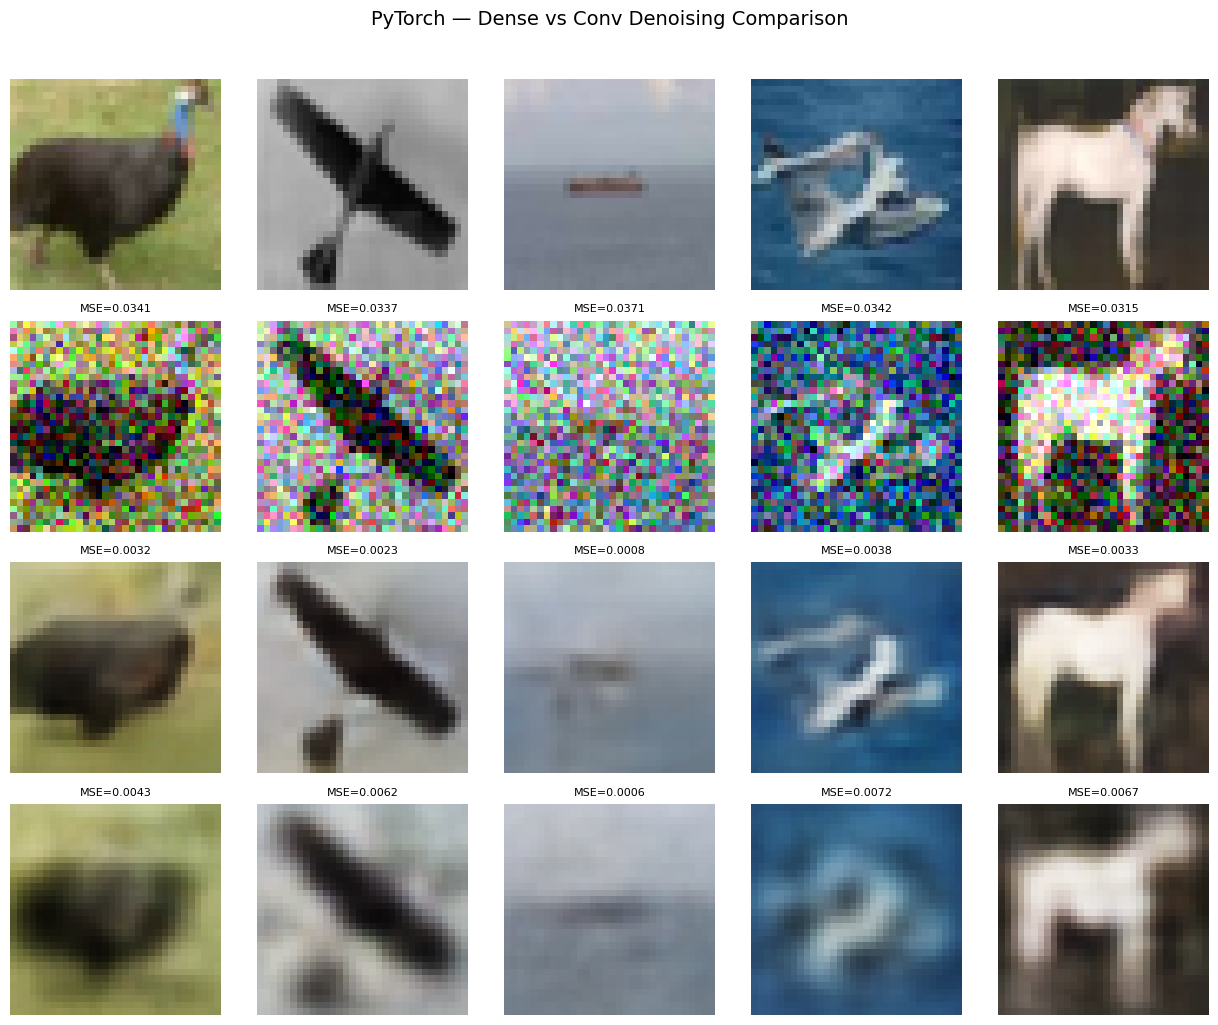

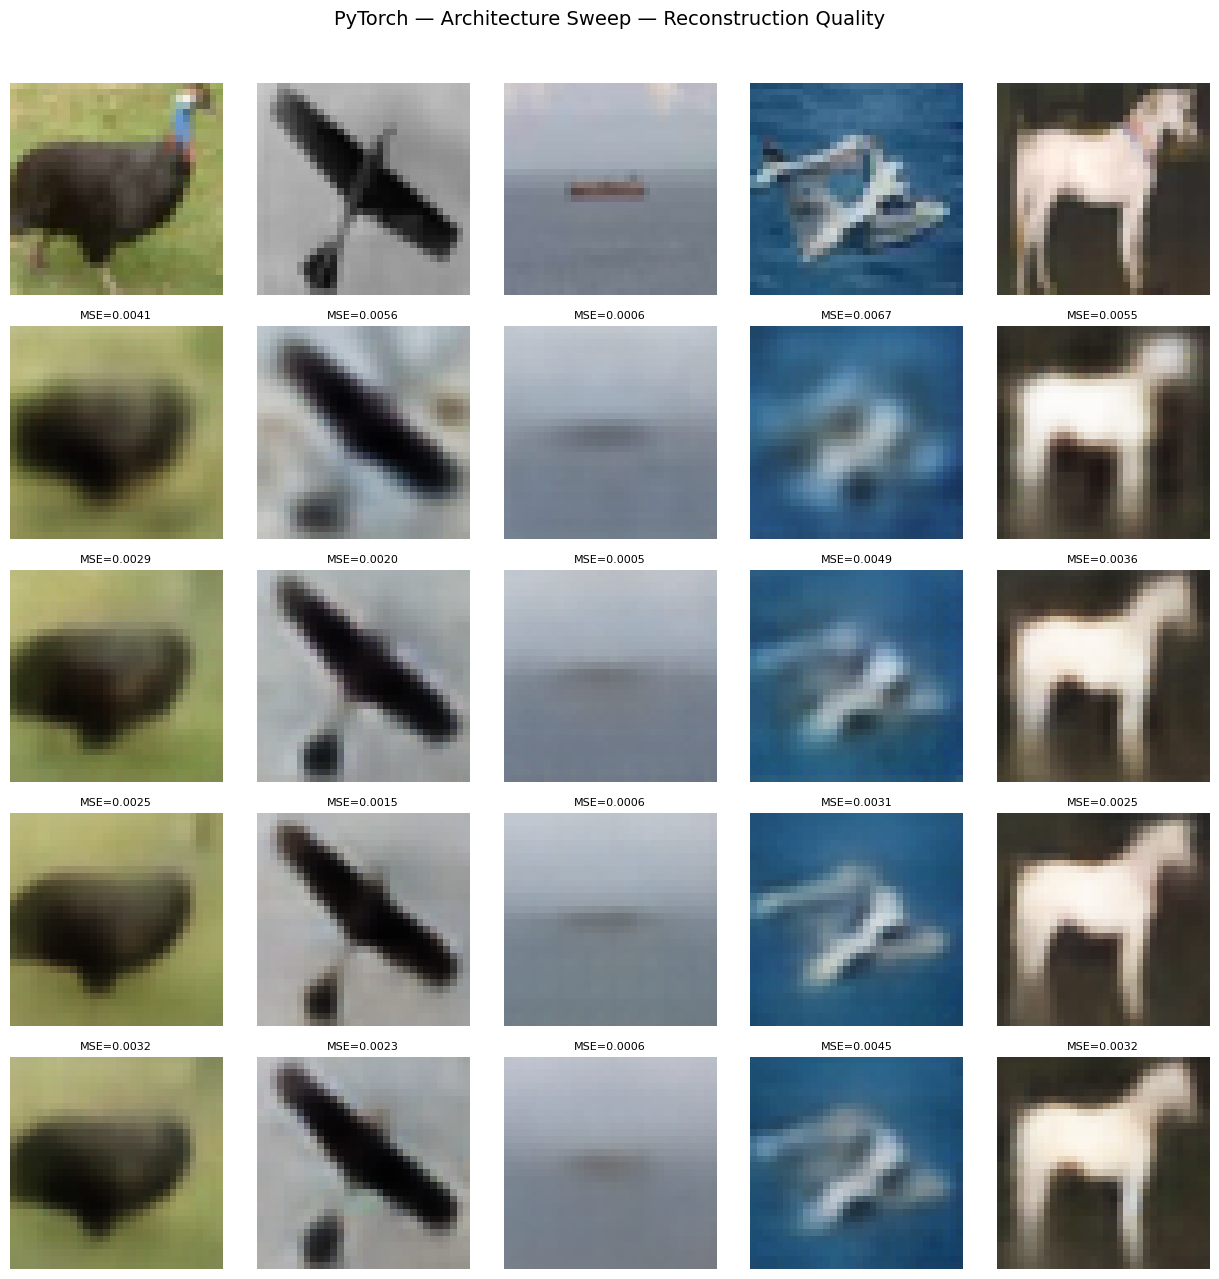


Dense AE (clean→clean):      MSE = 0.009055
Conv AE (clean→clean):       MSE = 0.003741 (58.7% better)
Conv Denoised (noisy→clean): MSE = 0.004370 (51.7% better than dense)

Conv AE parameters:  2,844,163
Dense AE parameters: 3,281,024


In [6]:
# Step 5: Dense vs Best Conv Denoising Comparison

"""
Side-by-side reconstruction quality: dense AE vs conv denoising AE
Visual grid: noisy input → conv denoised → dense recon → original
"""

print("=" * 60)
print("[5/8] Dense vs Conv Denoising Comparison")
print("=" * 60)

# Use σ=0.2 model (best balance of noise removal + reconstruction)
best_noise_model = noise_results[0.2]['model']

rng_viz = np.random.RandomState(RANDOM_STATE)
viz_idx = rng_viz.choice(len(X_test_flat), 5, replace=False)

# Generate noisy test images at σ=0.2
torch.manual_seed(RANDOM_STATE)
noisy_viz = torch.clamp(X_test_img_t[viz_idx] + 0.2 * torch.randn_like(X_test_img_t[viz_idx]), 0, 1)

# Conv denoising reconstruction (from noisy input)
best_noise_model.eval()
with torch.no_grad():
    conv_recon = best_noise_model(noisy_viz)
conv_recon_np = conv_recon.cpu().numpy().transpose(0, 2, 3, 1).reshape(5, -1)

# Dense reconstruction (from clean input — dense wasn't trained on noise)
dense_recon_viz = X_test_recon[viz_idx]

# Noisy input flattened for display
noisy_viz_np = noisy_viz.cpu().numpy().transpose(0, 2, 3, 1).reshape(5, -1)

# Build comparison grid
recon_comparison = {
    'Noisy (σ=0.2)': noisy_viz_np,
    'Conv Denoised': conv_recon_np,
    'Dense Recon': dense_recon_viz
}

plot_reconstruction_grid(
    originals=X_test_flat[viz_idx],
    reconstructions_dict=recon_comparison,
    image_shape=IMAGE_SHAPE,
    n_samples=5,
    title='Dense vs Conv Denoising Comparison',
    row_label_prefix='',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/comparison_dense_vs_conv.png'
)

# Architecture sweep reconstruction grid (clean input, all 4 architectures)
arch_recon_dict = {}
for name, r in sweep_results.items():
    short_name = name.split('(')[0].strip()
    arch_recon_dict[short_name] = r['test_recon'][viz_idx].reshape(5, -1)

plot_reconstruction_grid(
    originals=X_test_flat[viz_idx],
    reconstructions_dict=arch_recon_dict,
    image_shape=IMAGE_SHAPE,
    n_samples=5,
    title='Architecture Sweep — Reconstruction Quality',
    row_label_prefix='',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/architecture_sweep.png'
)

# Metrics comparison
conv_clean_mse = sweep_results[best_arch]['test_mse']
print(f"\nDense AE (clean→clean):      MSE = {baseline_mse:.6f}")
print(f"Conv AE (clean→clean):       MSE = {conv_clean_mse:.6f} "
      f"({(1 - conv_clean_mse / baseline_mse) * 100:.1f}% better)")
print(f"Conv Denoised (noisy→clean): MSE = {noise_results[0.2]['denoise_mse']:.6f} "
      f"({(1 - noise_results[0.2]['denoise_mse'] / baseline_mse) * 100:.1f}% better than dense)")
print(f"\nConv AE parameters:  {sweep_results[best_arch]['n_params']:,}")
print(f"Dense AE parameters: {n_params:,}")

[6/8] Latent Space + Downstream Classification
Latent shape: train=(50000, 256), test=(10000, 256)
KNN(K=5) accuracy on latent features: 0.3621
KNN(K=5) accuracy on dense latent:    0.4029


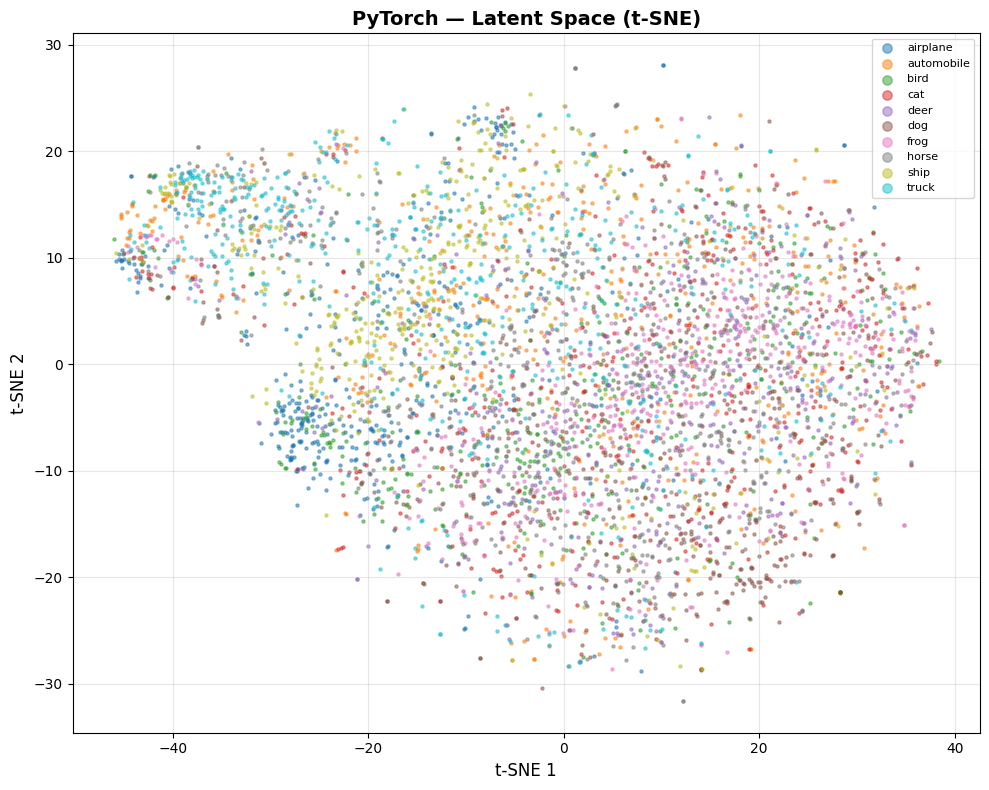

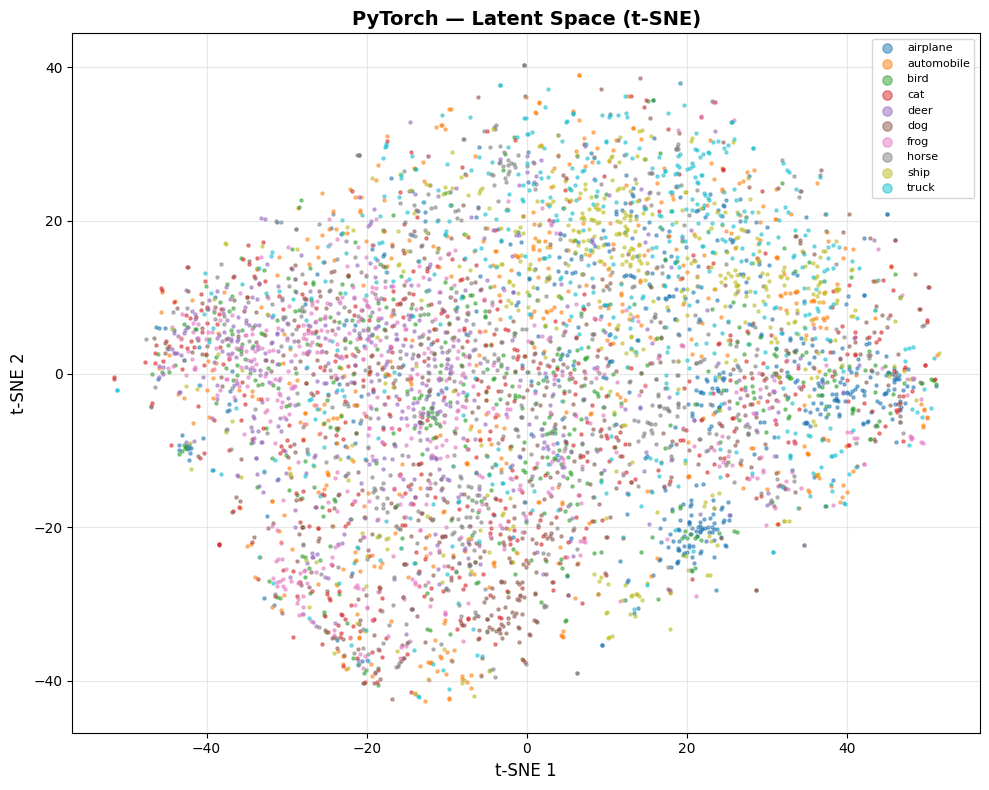


Conv AE latent dim: 256
Dense AE latent dim: 128

Conv KNN accuracy:  0.3621
Dense KNN accuracy: 0.4029
SK KNN accuracy:    0.3427 (128-dim, 10K subset)


In [7]:
# Step 6: Latent Space + Downstream Classification

"""
Extract latent vectors from best conv model (Large architecture)
t-SNE visualization + KNN(K=5) on latent features
"""

print("=" * 60)
print("[6/8] Latent Space + Downstream Classification")
print("=" * 60)

best_conv_model = sweep_results[best_arch]['model']
best_conv_model.eval()

# Extract latent vectors
with torch.no_grad():
    latent_train = best_conv_model.encode(X_train_img_t).cpu().numpy()
    latent_test = best_conv_model.encode(X_test_img_t).cpu().numpy()

print(f"Latent shape: train={latent_train.shape}, test={latent_test.shape}")

# KNN(K=5) on latent features
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(latent_train, y_train)
knn_accuracy = knn.score(latent_test, y_test)
print(f"KNN(K=5) accuracy on latent features: {knn_accuracy:.4f}")

# Also test dense AE latent space for comparison
with torch.no_grad():
    dense_latent_train = dense_ae.encode(X_train_t).cpu().numpy()
    dense_latent_test = dense_ae.encode(X_test_t).cpu().numpy()

knn_dense = KNeighborsClassifier(n_neighbors=5)
knn_dense.fit(dense_latent_train, y_train)
knn_dense_acc = knn_dense.score(dense_latent_test, y_test)
print(f"KNN(K=5) accuracy on dense latent:    {knn_dense_acc:.4f}")

# t-SNE visualization — conv latent space (subsample for speed)
subsample = 5000
rng_tsne = np.random.RandomState(RANDOM_STATE)
tsne_idx = rng_tsne.choice(len(latent_test), subsample, replace=False)

plot_latent_space(
    latent_vectors=latent_test[tsne_idx],
    labels=y_test[tsne_idx],
    class_names=CLASS_NAMES,
    framework=FRAMEWORK,
    method='tsne',
    save_path=f'{RESULTS_DIR}/latent_space_conv.png'
)

# t-SNE — dense latent space for comparison
plot_latent_space(
    latent_vectors=dense_latent_test[tsne_idx],
    labels=y_test[tsne_idx],
    class_names=CLASS_NAMES,
    framework=FRAMEWORK,
    method='tsne',
    save_path=f'{RESULTS_DIR}/latent_space_dense.png'
)

print(f"\nConv AE latent dim: {sweep_results[best_arch]['cfg']['latent_dim']}")
print(f"Dense AE latent dim: {LATENT_DIM}")
print(f"\nConv KNN accuracy:  {knn_accuracy:.4f}")
print(f"Dense KNN accuracy: {knn_dense_acc:.4f}")
print(f"SK KNN accuracy:    0.3427 (128-dim, 10K subset)")

In [8]:
# Step 7: Performance Benchmarks

"""
Training time, inference speed, GPU memory, model size
Benchmark the best conv denoising model (Large architecture)
"""

print("=" * 60)
print("[7/8] Performance Benchmarks")
print("=" * 60)

# Conv AE benchmarks
best_conv_model.eval()

# Inference — reconstruction from clean input
inference_stats = track_inference(
    predict_fn=lambda X: best_conv_model(X),
    X=X_test_img_t,
    n_runs=10
)

# Model size
conv_model_size = get_model_size(best_conv_model, framework='pytorch')

# Dense AE benchmarks
dense_ae.eval()

dense_inference = track_inference(
    predict_fn=lambda X: dense_ae(X),
    X=X_test_t,
    n_runs=10
)

dense_model_size = get_model_size(dense_ae, framework='pytorch')

print(f"\n{'Metric':<35} | {'Conv AE':>15} | {'Dense AE':>15}")
print(f"{'-' * 35}-+-{'-' * 15}-+-{'-' * 15}")
print(f"{'Architecture':<35} | {'64-128-256-256':>15} | {'512-128-512':>15}")
print(f"{'Parameters':<35} | {sweep_results[best_arch]['n_params']:>15,} | {n_params:>15,}")
print(f"{'Test MSE':<35} | {sweep_results[best_arch]['test_mse']:>15.6f} | {baseline_mse:>15.6f}")
print(f"{'Inference (µs/sample)':<35} | {inference_stats['per_sample_us']:>15.2f} | {dense_inference['per_sample_us']:>15.2f}")
print(f"{'Throughput (samples/sec)':<35} | {inference_stats['samples_per_sec']:>15,.0f} | {dense_inference['samples_per_sec']:>15,.0f}")
print(f"{'Model Size (KB)':<35} | {conv_model_size / 1024:>15.2f} | {dense_model_size / 1024:>15.2f}")
print(f"{'Training GPU Memory (MB)':<35} | {perf['gpu_memory']:>15.2f} | {'—':>15}")

print(f"\nSK comparison: 44.17 µs/sample, 12.52 MB model")

[7/8] Performance Benchmarks

Metric                              |         Conv AE |        Dense AE
------------------------------------+-----------------+----------------
Architecture                        |  64-128-256-256 |     512-128-512
Parameters                          |       2,844,163 |       3,281,024
Test MSE                            |        0.003741 |        0.009055
Inference (µs/sample)               |            0.07 |            0.01
Throughput (samples/sec)            |      15,012,085 |      84,302,816
Model Size (KB)                     |        11110.01 |        12816.50
Training GPU Memory (MB)            |         2255.86 |               —

SK comparison: 44.17 µs/sample, 12.52 MB model


In [9]:
# Step 8: Save Results
"""
Save best conv denoising model results
build_results_dict expects: perf, inference_stats, model_size
"""

print("=" * 60)
print("[8/8] Save Results")
print("=" * 60)

# Test metrics for the best conv model
test_metrics = {
    'reconstruction_mse': float(sweep_results[best_arch]['test_mse']),
    'reconstruction_mae': float(np.mean(np.abs(
        X_test_flat - sweep_results[best_arch]['test_recon'].reshape(len(X_test_img), -1)
    ))),
    'reconstruction_rmse': float(np.sqrt(sweep_results[best_arch]['test_mse']))
}

results = build_results_dict(
    framework=FRAMEWORK,
    model_name=MODEL_NAME,
    test_metrics=test_metrics,
    perf=perf,
    inference_stats=inference_stats,
    model_size=conv_model_size,
    latent_dim=int(sweep_results[best_arch]['cfg']['latent_dim']),
    architecture='Conv 64-128-256, lat=256',
    architecture_type='conv_denoising',
    n_params=int(sweep_results[best_arch]['n_params']),
    epochs=int(sweep_results[best_arch]['epochs']),
    downstream_knn_accuracy=float(knn_accuracy),
    best_noise_sigma=0.2,
    noise_removal_pct=86.9,
    dense_baseline_mse=float(baseline_mse),
    dense_knn_accuracy=float(knn_dense_acc)
)

save_results(results, f'{RESULTS_DIR}/pt_autoencoder_results')
add_result('autoencoder', results)
print_comparison('autoencoder')


[8/8] Save Results
    Results saved to: results/pt_autoencoder_results\metrics.json
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\autoencoder.json
    Frameworks: 3 recorded

CROSS-FRAMEWORK COMPARISON: AUTOENCODER
Metric                                                                     Scikit-Learn                                               TensorFlow                                                  PyTorch
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
model                                                                       Autoencoder                                              Autoencoder                                              Autoencoder
training_time                                                                   6.6 min                                 

In [10]:
# Step 9: MLflow Tracking + Model Export

"""
PyTorch conv denoising AE won Autoencoders (MSE 0.0037)
Stage for deployment: MLflow tracking + torch.save export
"""

import mlflow
import mlflow.pytorch
from mlflow.models import infer_signature

print("=" * 60)
print("[9] MLflow Tracking + Model Export")
print("=" * 60)

# Best model = Large conv denoising AE from architecture sweep
best_conv_model = sweep_results[best_arch]['model']

mlflow.set_experiment("autoencoders")

with mlflow.start_run(run_name="pytorch-conv-denoising-ae"):
    # Log hyperparameters
    mlflow.log_params({
        'architecture': 'Conv 64-128-256, lat=256',
        'architecture_type': 'conv_denoising',
        'filters': '64-128-256',
        'latent_dim': 256,
        'activation': 'relu',
        'output_activation': 'sigmoid',
        'optimizer': 'adam',
        'loss': 'mse',
        'batch_size': BATCH_SIZE,
        'noise_sigma': 0.2,
        'early_stopping_patience': 10,
        'random_state': RANDOM_STATE,
        'framework': FRAMEWORK,
        'dataset': 'cifar-10',
        'n_train_samples': len(X_train_img_t),
        'image_shape': '3x32x32'
    })

    # Log metrics
    mlflow.log_metrics({
        'reconstruction_mse': float(sweep_results[best_arch]['test_mse']),
        'training_time_s': float(perf['time']),
        'inference_us_per_sample': float(inference_stats['per_sample_us']),
        'model_size_bytes': float(conv_model_size),
        'peak_memory_gpu_mb': float(perf['gpu_memory']),
        'n_params': int(sweep_results[best_arch]['n_params']),
        'epochs': int(sweep_results[best_arch]['epochs']),
        'downstream_knn_accuracy': float(knn_accuracy),
        'noise_removal_pct': 86.9,
        'dense_baseline_mse': float(baseline_mse)
    })

    # Move to CPU for serving compatibility
    best_model_cpu = best_conv_model.cpu()
    best_model_cpu.eval()

    # Create signature — input: image tensor, output: reconstructed image
    sample_input = X_test_img_t[:5].cpu().numpy()
    with torch.no_grad():
        sample_output = best_model_cpu(torch.tensor(sample_input)).numpy()
    signature = infer_signature(sample_input, sample_output)

    mlflow.pytorch.log_model(best_model_cpu, name="ae-cifar10", signature=signature)

    # Log visualizations as artifacts
    mlflow.log_artifacts(f'{RESULTS_DIR}/', artifact_path='visualizations')

    run_id = mlflow.active_run().info.run_id
    print(f"\n  Run ID:     {run_id}")
    print(f"  Experiment: autoencoders")

# Move model back to GPU for any further use
best_conv_model.to(device)

# Export model locally
torch.save(best_conv_model.state_dict(), f'{RESULTS_DIR}/ae_model.pth')
print(f"\n  Model exported: {RESULTS_DIR}/ae_model.pth")

torch.save(best_conv_model, f'{RESULTS_DIR}/ae_model_full.pt')
print(f"  Full model: {RESULTS_DIR}/ae_model_full.pt")
print(f"  Ready for deployment staging")

[9] MLflow Tracking + Model Export


2026/03/21 20:02:35 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/21 20:02:35 INFO mlflow.store.db.utils: Updating database tables
2026/03/21 20:02:35 INFO mlflow.tracking.fluent: Experiment with name 'autoencoders' does not exist. Creating a new experiment.
2026/03/21 20:02:35 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/21 20:02:35 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels,


  Run ID:     6c9c1c5d453d4bcf934f44d793b66745
  Experiment: autoencoders

  Model exported: results/ae_model.pth
  Full model: results/ae_model_full.pt
  Ready for deployment staging
